# Tests to compare everything with each other

### vorher installieren:
-  pingouin
- matplotlib
- seaborn
-------

## 1. schauen welchen ANOVA ich machen muss

### => sind meinen Daten normalverteilt oder weichen sie signifikant von einer Normalverteilung ab! mit *Shapiro-Wilk-Test*
---
## Hypothesentest:
- Nullhypothese (H₀): Die Daten sind normalverteilt
- Alternativhypothese (H₁): Die Daten sind nicht normalverteilt
- p < 0.05 → Daten sind nicht normalverteilt
---
##  Wie funktioniert der Test:
- Werte werden der Größe nach sortiert
- Vergleich mit idealer Normalverteilung (Position der beobachteten Werte werden mit den erwarteten Positionen, wenn die Daten wirklich normalverteilt sind verglichen)
- dann Berechnung einer Teststatistik (Ergebnis ist eine Zahl zwischen 0 und 1; je näher W an 1, desto eher sehen die Daten normalverteilt aus; Test berechnet daraus einen p-Wer)
- p > 0.05 → H₀ wird nicht verworfen =  Daten könnten normalverteilt sein
- p ≤ 0.05 → H₀ wird verworfen = Daten sind nicht normalverteilt

In [33]:
import pandas as pd # für Datenverarbeitung
from scipy.stats import shapiro # Funktion für den Shapiro-wilk-Normalverteilungstest

# Datensatz laden
df = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")

# CDR-Regionen und Eigenscahften definieren 
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]
properties = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Schleife über alle Kombinationen
for region in regions:
    for property in properties:
        # Spaltenname erzeugen
        if property == "length": # prüft ob die aktuelle spalte length ist
            column = f"{region.lower()}_length" # wenn length dann wird region klein geschrieben (weil es so im df steht)
        else: # wenn nicht length dann wird region mit property direkt kombiniert 
            column = f"{region}_{property}"

# f-String um Variable direkt in text einzufügen; \n für Zeilenumbruch; {column} Name betrachtete Spalte
        print(f"\n Shapiro-Wilk-Test für: {column}") 


        # Daten pro Gruppen extrahieren
        for group in ["human", "sars_cov2", "influenza"]: # Schleife über die drei Gruppen
            values = df[df["source"] == group][column].dropna() # source und group müssen übereinstimmen
                                                                # [column] nur relevante Spalte (Bsp.CDR_H1_mean_mass)
                                                                # .dropna() Entfernt alle fehlenden Werte (NaN)
            # Shapiro-Wilk-Test anwenden                                       
            if len(values) >= 3: # Gibt die Anzahl der Werte in values zurück; >= 3 → Bedingung: Mindestens 3 Werte erforderlich
                _, p = shapiro(values) # Durchführung Shapiro-Wilk-Test; p → p-Wert (Wahrscheinlichkeit, dass Daten aus Normalverteilung stammen)
                result = " normalverteilt" if p > 0.05 else " nicht normalverteilt" # verkürzter if-else-Ausdruck; p > 0.05 → Bedingung

                # f-String; {group:<10} Gruppe wird eingesetzt mit : Beginn Formatierung < Linksbündig 10 min 10 Zeich.
                # p = p-Wert aus dem Shapiro-Wilk-Test; : Einleitung des Formatierungsteils; .4 4 Nachkommastellen; f Zeige die Zahl als float
                print(f"   Gruppe: {group:<10} → p = {p:.4f} → {result}")  
        



 Shapiro-Wilk-Test für: CDR_H1_mean_hydrophobicity
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0003 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.1536 →  normalverteilt

 Shapiro-Wilk-Test für: CDR_H1_mean_charge
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0000 →  nicht normalverteilt

 Shapiro-Wilk-Test für: CDR_H1_mean_polarity
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0877 →  normalverteilt

 Shapiro-Wilk-Test für: CDR_H1_mean_mass
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0207 →  nicht normalverteilt

 Shapiro-Wilk-Test für: cdr_h1_length
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  

### ! Unesere Daten sind nicht normalverteilt !
---

### => dann schauen wie die Varianz ist mit:
## *Levene-Test*
---
### wie funktioniert der Test ?
- prüft, ob die Varianzen mehrerer Gruppen gleich sind

=> Varianz = Maß dafür, wie weit Werte vom Mittelwert abweichen

- man braucht mehrere Gruppen mit Messwerten
- Für jede Gruppe wird der Mittelwert berechnet.
- Jeder Wert wird durch seinen absoluten Abstand zum Gruppenmittelwert ersetzt.
- Auf diesen Abständen wird eine einfache ANOVA durchgeführt.
- Der resultierende F-Wert und p-Wert zeigen, ob die Varianzen signifikant unterschiedlich sind (hier wird nur der p-Wert angezeigt)

#### ! Nullhypothese (H₀): Die Varianzen der Gruppen sind gleich.
#### - p-Wert < 0.05 → Ablehnung der Nullhypothese → Varianzen sind unterschiedlich → Welch-ANOVA
#### - p-Wert ≥ 0.05 → Nullhypothese wird nicht abgelehnt → Varianzen sind gleich →  klassische ANOVA möglich

In [34]:
from scipy.stats import levene  # Funktion für den Levene-Test (Varianzvergleich)

# Schleife über alle Kombinationen
for region in regions:
    for property in properties:
        # Spaltenname erzeugen
        if property == "length":  # prüft ob die aktuelle Spalte 'length' ist
            column = f"{region.lower()}_length"  # wenn 'length', dann wird region klein geschrieben (weil es so im df steht)
        else:  # wenn nicht 'length', dann wird region mit property direkt kombiniert
            column = f"{region}_{property}"

        # f-String um Variable direkt in Text einzufügen; \n für Zeilenumbruch; {column} = Name der betrachteten Spalte
        print(f"\n Levene-Test für: {column}")

        # Daten pro Gruppe extrahieren
        for group in ["human", "sars_cov2", "influenza"]:  # Schleife über die drei Gruppen
            df[f"{group}_values"] = df[df["source"] == group][column].dropna()
            # Diese Zuweisung erstellt temporär drei neue Serien im df: z. B. df["human_values"]

        # Zugriff auf die Serien
        group_human = df["human_values"].dropna()
        group_sars = df["sars_cov2_values"].dropna()
        group_influenza = df["influenza_values"].dropna()

        # Levene-Test anwenden
        if len(group_human) >= 3 and len(group_sars) >= 3 and len(group_influenza) >= 3:
            stat, p = levene(group_human, group_sars, group_influenza)  # Durchführung Levene-Test
            result = " Varianzen gleich → klassische ANOVA möglich" if p > 0.05 else " Varianzen ungleich → Welch-ANOVA empfohlen"

            # f-String; {p:.4f} formatiert den p-Wert mit 4 Nachkommastellen
            print(f"   p = {p:.4f} →{result}")
        else:
            print("   !  Nicht genug Daten in einer oder mehreren Gruppen (mind. 3 pro Gruppe erforderlich)")



 Levene-Test für: CDR_H1_mean_hydrophobicity
   p = 0.0295 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H1_mean_charge
   p = 0.0182 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H1_mean_polarity
   p = 0.2748 → Varianzen gleich → klassische ANOVA möglich

 Levene-Test für: CDR_H1_mean_mass
   p = 0.0000 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: cdr_h1_length
   p = 0.0000 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_hydrophobicity
   p = 0.0007 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_charge
   p = 0.6016 → Varianzen gleich → klassische ANOVA möglich

 Levene-Test für: CDR_H2_mean_polarity
   p = 0.0153 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_mass
   p = 0.0004 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: cdr_h2_length
   p = 0.0000 → Varianzen ungleich → Welch-ANOVA empfohlen

 Levene-Test für: CDR

### => unsere Daten haben zum größten Teil eine ungleiche Varianz => Welch-ANOVA empfohlen
---

## 2. Welche ANOVA
### => Die Welch-ANOVA testet, ob die Mittelwerte von drei oder mehr Gruppen signifikant unterschiedlich sind – ohne die Annahme gleicher Varianzen

### wie funktioniert der Test:
- zuert wird der Gruppenmittelwert berechnet 
- Gruppenvarianzen und Gruppengrößen berücksichtigen
- gewichteter Mittelwert bezieht Gruppengrößen und Varianzen mit ein
- dann wird die Teststatistik berechnet (ewichtete Varianz der Gruppenmittelwerrte / angepasste Streunung innerhalb der Gruppeng)
- die Freiheitsgrade werden angepasst (mit Welch-Satterthwaite-Gleichung um kleine Gruppen oder starke Varianzunterschiede zu berücksichtigen)
- dann wird noch der p-Wert berechnet (aus Basis der angepassten F-Statistik und der Freiheitsgrade)
---
#### F-Wert = Teststatistik der Welch-ANOVA
- misst, wie groß der Unterschied der Mittelwerte zwischen den Gruppen ist, relativ zur Streuung innerhalb der Gruppen
- F = ewichtete Varianz der Gruppenmittelwerrte / angepasste Streunung innerhalb der Gruppeng
- Je größer der F-Wert, desto größer der Unterschied zwischen den Gruppenmittelwerten im Verhältnis zur inneren Streuung
- ! Aber der F-Wert allein sagt aber noch nicht, ob der Unterschied signifikant ist
#### P-Wert
- p < 0.05 → Der Unterschied ist statistisch signifikant
- p ≥ 0.05 → Der Unterschied könnte zufällig sein
---

In [35]:
import pingouin as pg  # Programm für Welch-ANOVA

# Schleife über alle Kombinationen (doppelte Schleife)
for region in regions:
    for property in properties:

        # Spaltenname erzeugen
        if property == "length":  # prüft, ob die aktuelle Spalte 'length' ist
            column = f"{region.lower()}_length"  # wenn 'length', dann wird region klein geschrieben (weil es so im df steht)
        else:  # wenn nicht 'length', dann wird region mit property direkt kombiniert
            column = f"{region}_{property}"

        print(f"\n Welch-ANOVA für: {column}")  # Gibt aus, welche Spalte gerade analysiert wird; \n für Zeilenumbruch

        # DataFrame für Welch-ANOVA vorbereiten
        data = df[['source', column]].dropna()  # Datenframe nur mit relevanten Spalten für den Test
        data = data.rename(columns={'source': 'group', column: 'value'})  # Spalten umbenennen für Pingouin

        # Prüfen ob genug Daten vorhanden sind
        if data['group'].value_counts().min() < 3:  # zählt, wie viele Werte jede Gruppe hat
            print("   !  Nicht genug Daten in mindestens einer Gruppe")
            continue

        # Welch-ANOVA durchführen
        result = pg.welch_anova(dv='value', between='group', data=data) # dv='value': die abhängige Variable

        # Ausgabe
        f_val = result['F'].values[0]
        p_val = result['p-unc'].values[0]
        print(f"   F-Wert = {f_val:.4f}, p-Wert = {p_val:.4f}")

        if p_val < 0.05:
            print("     Signifikanter Unterschied zwischen Gruppen")
        else:
            print("   !  Kein signifikanter Unterschied gefunden")



 Welch-ANOVA für: CDR_H1_mean_hydrophobicity
   F-Wert = 23.8336, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H1_mean_charge
   F-Wert = 1.0091, p-Wert = 0.3659
   !  Kein signifikanter Unterschied gefunden

 Welch-ANOVA für: CDR_H1_mean_polarity
   F-Wert = 21.0009, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H1_mean_mass
   F-Wert = 23.9210, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: cdr_h1_length
   F-Wert = 12.3406, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_hydrophobicity
   F-Wert = 6.9225, p-Wert = 0.0012
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_charge
   F-Wert = 6.3298, p-Wert = 0.0021
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_polarity
   F-Wert = 1.6715, p-Wert = 0.1899
   !  Kein signifikanter Unterschied gefunden

 Welch-ANO

### => wir haben viele signifikante Unterschiede 
---

## 3. Games-Howell-Test (post-hoc Analyse)
### => um herauszufinden welche Gruppen sich voneinander unterscheiden
### => Ergebnisse dann in einem Datensatz abspeicher 
---
### wie funktioniert der Test:
- Alle Gruppenpaare werden einzeln verglichen 
- Für jedes Paar wird berechnet: Unterschied der Mittelwerte; Standardfehler, der ungleiche Varianzen und Gruppengrößen berücksichtigt; ein t-ähnlicher Wert für den Gruppenvergleich; ein angepasster Freiheitsgrad
- Daraus ergibt sich: ein p-Wert = Gibt an, ob der Unterschied signifikant und eine Effektgröße (Hedges) = Wie groß ist der Unterschied
---
### pval (p-Wert) => ist der Unterschied echt oder nur Zufall?
- Gibt an, ob der Unterschied zwischen zwei Gruppen statistisch signifikant ist 
- p < 0.05 → Der Unterschied ist statistisch signifikant
- p ≥ 0.05 → Der Unterschied könnte zufällig sein
### hedges (Hedges) = Wie stark ist der Unterschied?
- Gibt die Effektgröße an
- 0,2 = kleiner Effekt
- 0,5 = mittlerer Effekt
- 0,8 oder mehr = großer Effekt


In [36]:
import os  # Modul installieren um später Verzeichnisse zu erstellen und Dateipfade zu handhaben

# Liste für Ergebnisse
all_results = []  # leere Liste = in der später alle signifikanten Testergebnisse gespeichert werden

# Schleife über alle Kombinationen (Doppelschleife)
for region in regions:
    for property in properties:
        # Spaltenname erzeugen
        if property == "length":  # prüft ob die aktuelle Spalte 'length' ist
            column = f"{region.lower()}_length"  # wenn 'length', dann wird region klein geschrieben (weil es so im df steht)
        else:  # wenn nicht 'length', dann wird region mit property direkt kombiniert 
            column = f"{region}_{property}"

        print(f"\n Games-Howell-Test für: {column}")  # Kontrolle: zeigt welche Spalte gerade getestet wird

        # Daten vorbereiten
        data = df[['source', column]].dropna()  # nur Daten aus 'source' und der Spalte column (mit Eigenschaft) werden geholt
        data = data.rename(columns={"source": "group", column: "value"})  # Spalten umbenennen: "source" wird zu "group"; column wird zu "value"

        # Genug Daten?
        if data['group'].value_counts().min() < 3:  # prüft ob jede Gruppe mindestens 3 Werte hat
            print("   !  Nicht genug Daten in mindestens einer Gruppe – übersprungen")
            continue

        # Welch-ANOVA
        anova = pg.welch_anova(dv='value', between='group', data=data)  # Welch-ANOVA-Test: dv='value' = abhängige Variable; between='group' = Gruppierung
        p_anova = anova['p-unc'].values[0]  # holt den unkorrigierten p-Wert aus dem Ergebnis des Tests

        if p_anova < 0.05:
            # Post-hoc Games-Howell
            gh = pg.pairwise_gameshowell(dv='value', between='group', data=data)
            gh['feature'] = column  # Spalte hinzufügen, um später zu wissen, auf welche Eigenschaft sich das Ergebnis bezieht
            all_results.append(gh[['feature', 'A', 'B', 'pval', 'hedges']])  # relevante Spalten an Ergebnisliste anhängen
            print("  !  Signifikanter Unterschied → Ergebnisse gespeichert.")

# Alle Ergebnisse zusammenfassen und speichern
if all_results:  # Wenn die Liste all_results nicht leer ist
    final_df = pd.concat(all_results, ignore_index=True)  # Alle Ergebnisse zusammenführen
    output_dir = "../../generated/stat_tests"  # Zielordner
    os.makedirs(output_dir, exist_ok=True)  # Ordner erstellen, falls er nicht existiert
    final_df.to_csv(os.path.join(output_dir, "games_howell_results.tsv"), sep="\t", index=False)  # Ergebnisse speichern
    print("\n Alle Ergebnisse gespeichert in 'games_howell_results.tsv'")  # Bestätigung ausgeben
else:
    print("\n Keine signifikanten Ergebnisse zum Speichern vorhanden.")  # Falls keine Tests signifikant waren



 Games-Howell-Test für: CDR_H1_mean_hydrophobicity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H1_mean_charge

 Games-Howell-Test für: CDR_H1_mean_polarity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H1_mean_mass
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: cdr_h1_length
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_hydrophobicity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_charge
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_polarity

 Games-Howell-Test für: CDR_H2_mean_mass
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: cdr_h2_length
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H3_mean_hydrophobicity

 Games-Howell-Test für: CDR_H3_mean_charge
  

In [37]:
# TSV-Datei einlesen
df = pd.read_csv("../../generated/stat_tests/games_howell_results.tsv", sep="\t")

# Ersten Zeilen anzeigen
print(df.head(10))  # Zeigt die ersten 10 Zeilen

                      feature          A          B          pval    hedges
0  CDR_H1_mean_hydrophobicity      human  influenza  1.162322e-04  0.527800
1  CDR_H1_mean_hydrophobicity      human  sars_cov2  1.492001e-04 -0.275975
2  CDR_H1_mean_hydrophobicity  influenza  sars_cov2  4.301754e-09 -0.754623
3        CDR_H1_mean_polarity      human  influenza  7.214908e-09 -0.753434
4        CDR_H1_mean_polarity      human  sars_cov2  6.641457e-01 -0.059067
5        CDR_H1_mean_polarity  influenza  sars_cov2  5.081615e-08  0.721689
6            CDR_H1_mean_mass      human  influenza  1.147730e-06  0.701651
7            CDR_H1_mean_mass      human  sars_cov2  1.118079e-07  0.373359
8            CDR_H1_mean_mass  influenza  sars_cov2  5.456181e-02 -0.270666
9               cdr_h1_length      human  influenza  1.233538e-05 -0.849888


## 4. Ergebnisse Veranschaulischen


### ! „Wie stark unterscheiden sich Gruppenmittelwerte in einer Eigenschaft?“
---


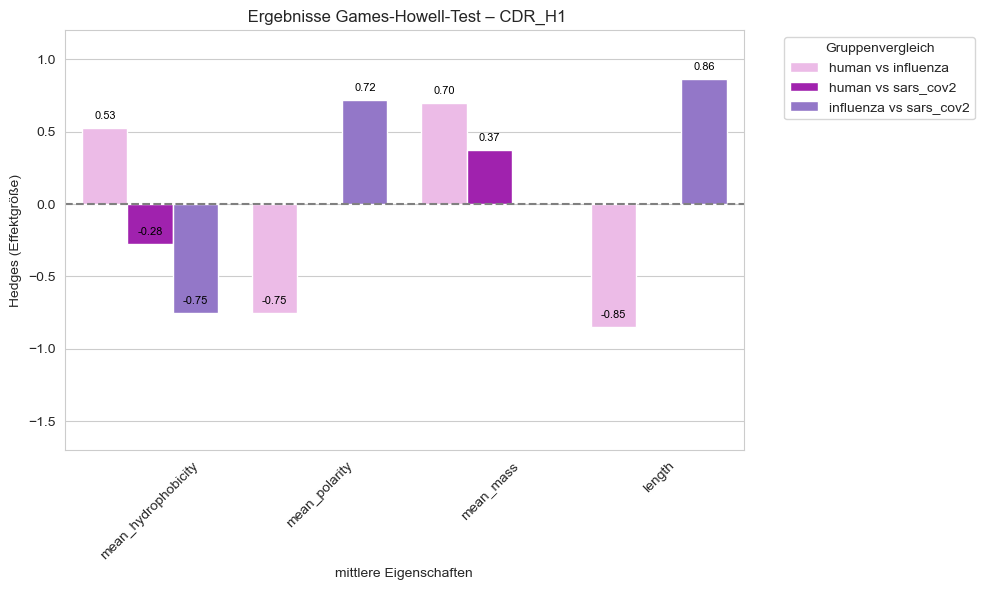

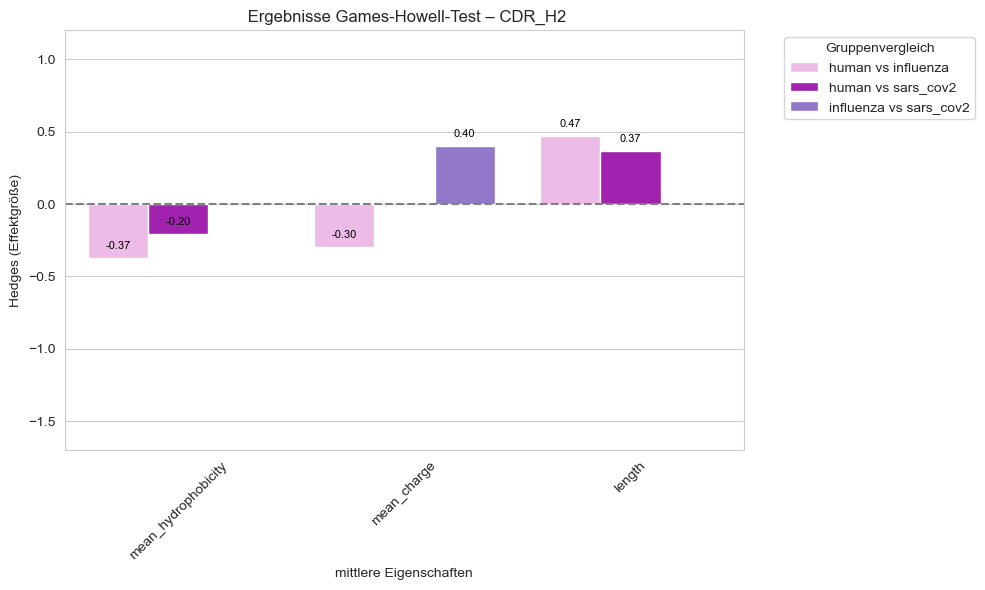

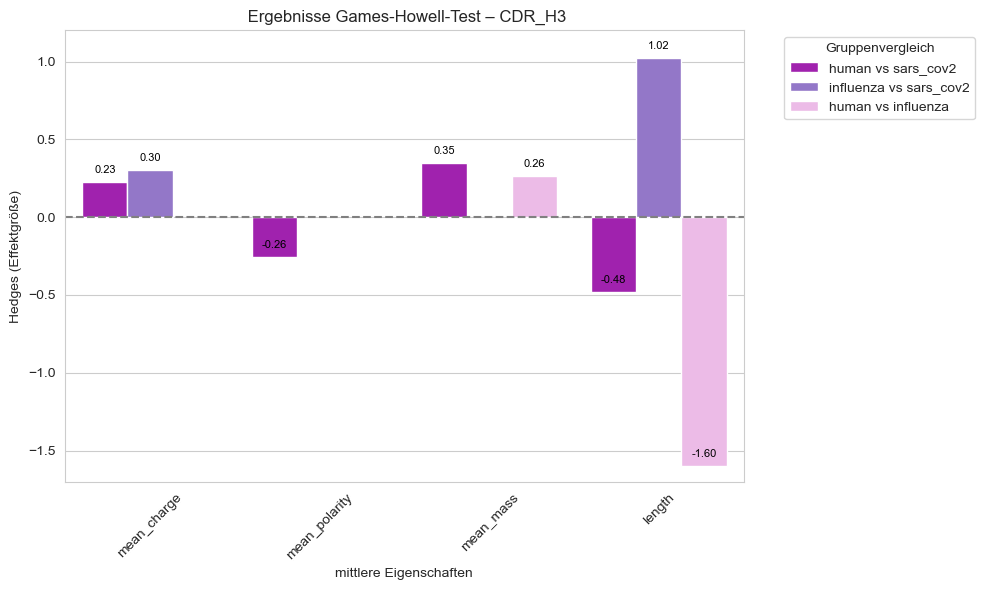

In [38]:
import matplotlib.pyplot as plt  # zum Zeichnen der Plots
import seaborn as sns  # für schöneres Plotdesign

# Stil für Gitterlinien aktivieren
sns.set_style("whitegrid")  # aktiviert weißen Hintergrund mit Gitterlinien für bessere Lesbarkeit

# Nur signifikante Ergebnisse
df_sig = df[df["pval"] < 0.05].copy()  # filtert nur signifikante Ergebnisse (p-Wert < 0.05); .copy() erstellt eine unabhängige Kopie

df_sig["pair"] = df_sig["A"] + " vs " + df_sig["B"]  # neue Spalte mit Gruppenvergleich

df_sig["region"] = df_sig["feature"].str.extract(r'(CDR_H\d|cdr_h\d)', expand=False)  # extrahiert die CDR-Region aus der Spalte "feature"

df_sig["property"] = df_sig["feature"].str.replace(r'(CDR_H\d|cdr_h\d)_?', '', regex=True)  # entfernt region aus der Spalte "feature", übrig bleibt die Eigenschaft (z. B. "mean_charge")

# Farbpalette für Gruppenvergleiche
custom_colors = {
    "human vs influenza": "#f4b3ee",         # helle rosa Farbe
    "human vs sars_cov2": "#b30bc5",         # kräftiges Lila
    "influenza vs sars_cov2": "#8F6AD5"      # blasses Violett
}

# Regionen durchgehen
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]  # Liste der Regionen, die einzeln geplottet werden sollen

for region in regions:  # Schleife über alle Regionen
    df_region = df_sig[df_sig["region"].str.lower() == region.lower()]  # nur Daten für die aktuelle Region auswählen

    if df_region.empty:  # überspringen, wenn es keine signifikanten Ergebnisse für die Region gibt
        continue

    plt.figure(figsize=(10, 6))  # neue Plotfläche mit Größe 10x6 Zoll
    ax = sns.barplot(  # Barplot zeichnen
        data=df_region,              # Datenquelle
        x="property",                # x-Achse = Eigenschaft 
        y="hedges",                  # y-Achse = Effektgröße
        hue="pair",                  # Balkenfarben unterscheiden nach Gruppenpaaren
        palette=custom_colors        # vorher definierte Farben verwenden
    )

    # Effektgrößen als Zahlen über die Balken schreiben
    for container in ax.containers:  # über alle Balkengruppen iterieren
        for bar in container:  # über jeden einzelnen Balken
            height = bar.get_height()  # Höhe (Effektgröße)
            if height != 0:  # nur wenn die Effektgröße ≠ 0 ist
                ax.annotate(f"{height:.2f}",  # Text: Effektgröße mit 2 Nachkommastellen
                            xy=(bar.get_x() + bar.get_width() / 2, height),  # Position auf dem Balken
                            xytext=(0, 5),  # Abstand nach oben
                            textcoords="offset points",  # Verschiebung relativ zum Punkt
                            ha='center', va='bottom',  # horizontal & vertikal zentriert
                            fontsize=8, color='black')  # Textstil

    plt.axhline(0, color="gray", linestyle="--")  # Horizontale Linie bei y=0 zur besseren Einordnung
    plt.title(f" Ergebnisse Games-Howell-Test – {region}")  # Titel des Plots mit aktueller Region
    plt.ylabel("Hedges (Effektgröße)")  # Beschriftung y-Achse
    plt.xlabel("mittlere Eigenschaften")  # Beschriftung x-Achse
    plt.xticks(rotation=45)  # Dreht die Eigenschaftsnamen um 45° für bessere Lesbarkeit
    plt.ylim(-1.70, 1.20)  # y-Achse festlegen, damit alle Plots gleich skaliert sind
    plt.legend(title="Gruppenvergleich", bbox_to_anchor=(1.05, 1), loc='upper left')  # Legende rechts außen
    plt.tight_layout()  # Verhindert, dass Achsentitel oder Legende abgeschnitten werden
    plt.show()  # Plot anzeigen


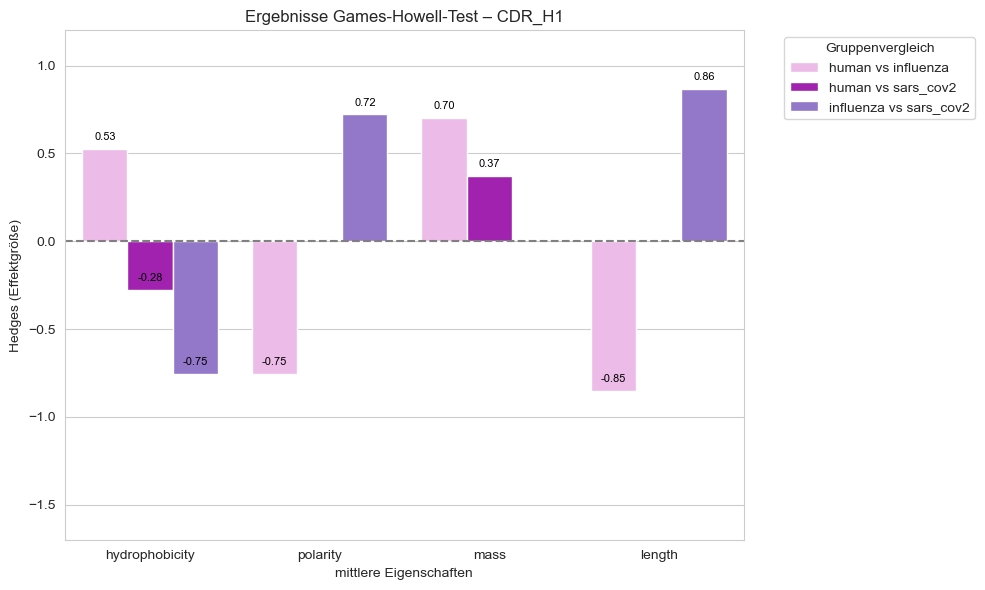

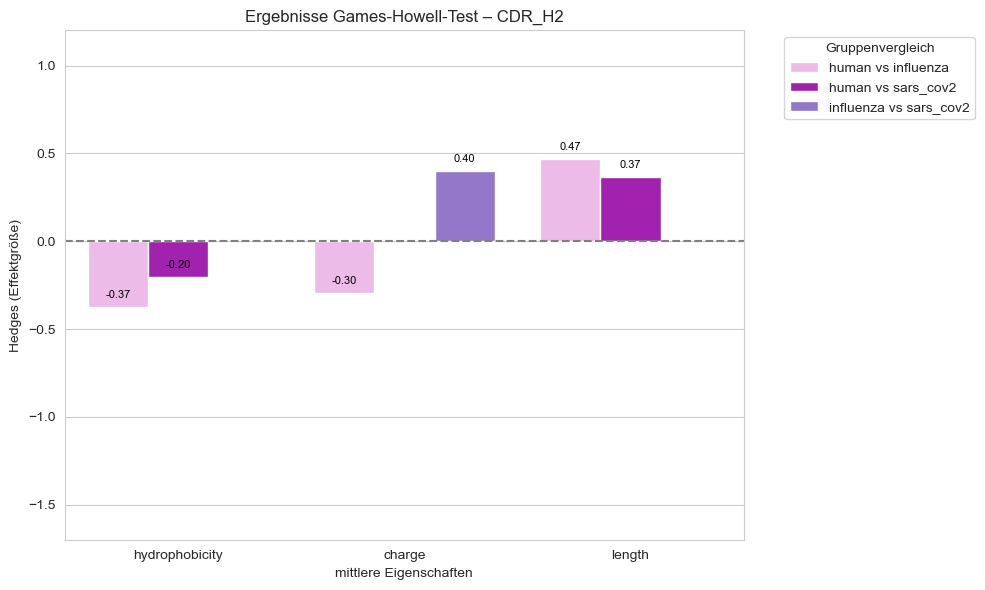

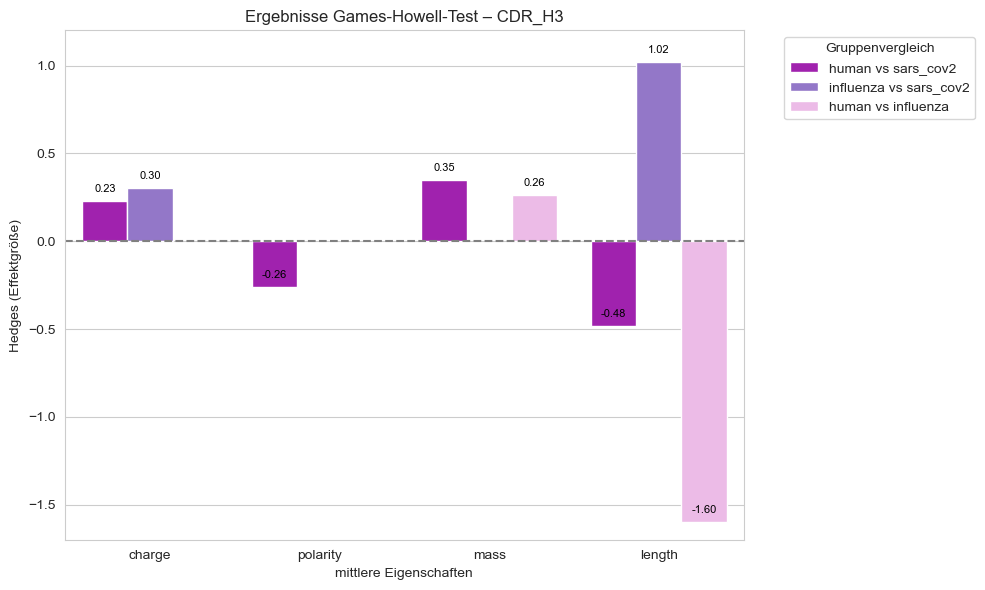

In [39]:
import matplotlib.pyplot as plt  # zum Zeichnen der Plots
import seaborn as sns  # für schöneres Plotdesign

# Stil für Gitterlinien aktivieren
sns.set_style("whitegrid")  # aktiviert weißen Hintergrund mit Gitterlinien für bessere Lesbarkeit

# Nur signifikante Ergebnisse
df_sig = df[df["pval"] < 0.05].copy()  # filtert nur signifikante Ergebnisse (p-Wert < 0.05); .copy() erstellt eine unabhängige Kopie

df_sig["pair"] = df_sig["A"] + " vs " + df_sig["B"]  # neue Spalte mit Gruppenvergleich

df_sig["region"] = df_sig["feature"].str.extract(r'(CDR_H\d|cdr_h\d)', expand=False)  # extrahiert die CDR-Region aus der Spalte "feature"

df_sig["property"] = df_sig["feature"].str.replace(r'(CDR_H\d|cdr_h\d)_?', '', regex=True)  # entfernt region aus der Spalte "feature", übrig bleibt die Eigenschaft (z. B. "mean_charge")

df_sig["property"] = df_sig["property"].str.replace(r'^mean_', '', regex=True)  # 🔧 entfernt das Präfix "mean_" aus den Eigenschaftsnamen für die x-Achse

# Farbpalette für Gruppenvergleiche
custom_colors = {
    "human vs influenza": "#f4b3ee",         # helle rosa Farbe
    "human vs sars_cov2": "#b30bc5",         # kräftiges Lila
    "influenza vs sars_cov2": "#8F6AD5"      # blasses Violett
}

# Regionen durchgehen
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]  # Liste der Regionen, die einzeln geplottet werden sollen

for region in regions:  # Schleife über alle Regionen
    df_region = df_sig[df_sig["region"].str.lower() == region.lower()]  # nur Daten für die aktuelle Region auswählen

    if df_region.empty:  # überspringen, wenn es keine signifikanten Ergebnisse für die Region gibt
        continue

    plt.figure(figsize=(10, 6))  # neue Plotfläche mit Größe 10x6 Zoll
    ax = sns.barplot(  # Barplot zeichnen
        data=df_region,              # Datenquelle
        x="property",                # x-Achse = Eigenschaft 
        y="hedges",                  # y-Achse = Effektgröße
        hue="pair",                  # Balkenfarben unterscheiden nach Gruppenpaaren
        palette=custom_colors        # vorher definierte Farben verwenden
    )

    # Effektgrößen als Zahlen über die Balken schreiben
    for container in ax.containers:  # über alle Balkengruppen iterieren
        for bar in container:  # über jeden einzelnen Balken
            height = bar.get_height()  # Höhe (Effektgröße)
            if height != 0:  # nur wenn die Effektgröße ≠ 0 ist
                ax.annotate(f"{height:.2f}",  # Text: Effektgröße mit 2 Nachkommastellen
                            xy=(bar.get_x() + bar.get_width() / 2, height),  # Position auf dem Balken
                            xytext=(0, 5),  # Abstand nach oben
                            textcoords="offset points",  # Verschiebung relativ zum Punkt
                            ha='center', va='bottom',  # horizontal & vertikal zentriert
                            fontsize=8, color='black')  # Textstil
    plt.axhline(0, color="gray", linestyle="--")  # Horizontale Linie bei y=0 zur besseren Einordnung
    plt.title(f"Ergebnisse Games-Howell-Test – {region}")  # Titel des Plots mit aktueller Region
    plt.ylabel("Hedges (Effektgröße)")  # Beschriftung y-Achse
    plt.xlabel("mittlere Eigenschaften")  # Beschriftung x-Achse
    plt.xticks(rotation=0)  # 🔧 Setzt die Beschriftung der x-Achse waagrecht (0°)
    plt.ylim(-1.70, 1.20)  # y-Achse festlegen, damit alle Plots gleich skaliert sind
    plt.legend(title="Gruppenvergleich", bbox_to_anchor=(1.05, 1), loc='upper left')  # Legende rechts außen
    plt.tight_layout()  # Verhindert, dass Achsentitel oder Legende abgeschnitten werden
    plt.show()  # Plot anzeigen

    


## 5. Interpretation der Diagramme

### => Ergebnisse mit der größten Effektstärke 
### Hedges: 
= ist eine Effektgröße zur Quantifizierung von Mittelwertunterschieden zwischen Gruppen

- Positiv: Die erste Gruppe hat einen höheren Mittelwert als die zweite
- Negativ: Die erste Gruppe hat einen niedrigeren Mittelwert als die zweite.
Je größer der Betrag, desto stärker ist der Unterschied
---

## CDR H3

### 1. mean_charge
#### - human vs. sars_cov2: g ≈ 0.23 → kleiner Effekt
#### - influenza vs. sars_cov2: g ≈ 0.30 → kleiner Effekt
#### ➤ SARS-CoV-2 hat eine geringere mittlere Ladung als die anderen beiden Gruppen.
---

### 2. mean_polarity
#### -human vs. sars_cov2: g ≈ -0.26 → kleiner Effekt
#### ➤ Die mittlere Polarität bei human ist niedriger als bei SARS-CoV-2.
---

### 3. mean_mass
####  -human vs. sars_cov2: g ≈ 0.35 → kleiner Effekt
#### - human vs. influenza: g ≈ 0.26 → kleiner Effekt
#### ➤ Human-Antikörper in CDR_H3 sind massereicher als bei den Viren.
---
### 4. length
#### - influenza vs. sars_cov2: g ≈ 1.02 → großer Effekt
#### - human vs. sars_cov2: g ≈ -0.48 → kleiner Effekt
#### - human vs. influenza: g ≈ -1.60 → großer Effekt
#### ➤ Influenza-CDR_H3 ist deutlich länger als bei human und SARS-CoV-2.
#### ➤ Human-CDR_H3 ist am kürzesten – sehr starker Unterschied zu influenza !!!
#### => Die größten Unterschiede findet man beim Länge der CDR_H3-Region: Influenza-Antikörper haben hier deutlich längere CDR_H3-Loops
---


## CDR H2

### 1. mean_hydrophobicity
#### - human vs influenza: g = -0.37
#### - human vs sars_cov2: g = -0.20
#### => Human-CDR_H2 ist weniger hydrophob als Influenza oder SARS-CoV-2
#### - Effektstärken: klein bis moderat
---

### 2. mean_charge
#### - influenza vs sars_cov2: g = 0.40
#### - human vs influenza: g = -0.30
#### => Influenza hat höhere mittlere Ladung als human und SARS-CoV-2
#### => Effekt klein bis mittel
---

### 5. length
#### - human vs influenza: g = 0.47
#### - human vs sars_cov2: g = 0.37
#### => Human-Antikörper haben längere CDR_H2-Regionen als die viralen Gruppen
#### => Effektgrößen nahe der mittleren Schwelle
---



## CDR H1 

### 1. mean_hydrophobicity
####  - human vs influenza: g = 0.53 → Human ist hydrophober
#### - human vs sars_cov2: g = -0.28 → Human weniger hydrophob als SARS-CoV-2
#### - influenza vs sars_cov2: g = -0.75 → Influenza deutlich weniger hydrophob als SARS-CoV-2
#### => SARS-CoV-2 ist die hydrophobste Gruppe in CDR_H1
---

### 2. mean_polarity
#### - human vs influenza: g = -0.75 → Influenza ist polarer als Human
#### - influenza vs sars_cov2: g = 0.72 → Influenza ist polarer als SARS-CoV-2
#### => Influenza ist am polarsten
---

### 3. mean_mass
#### - human vs influenza: g = 0.70 → Human ist schwerer als influenza
#### - human vs sars_cov2: g = 0.37 → Human > SARS-CoV-2
---
### 4. length
#### - human vs influenza: g = -0.85 → Human-CDR_H1 ist kürzer als Influenza 
#### - influenza vs sars_cov2: g = 0.87 → Influenza-CDR_H1 ist länger als SARS-CoV-2
#### => Influenza am längsten 
#### => Größter Effekt im ganzen Plot → Länge unterscheidet sich sehr deutlich
---



## 6. Interpretation der Ergebnisse:
## ! es weden nur Gruppen angezeigt die einen signifikanten p-Wert haben
#### - X-Achse: Eigenschaften 
#### - Y-Achse: Effektstärke (Hedges) → misst die Größe des Unterschieds zwischen Gruppen
#### => Wert > 0: Gruppe B hat im Mittel größere Werte als Gruppe A.
#### => Wert < 0: Gruppe A hat im Mittel größere Werte als Gruppe B.
#### => Wert ≈ 0: Kein oder nur kleiner Unterschied
---